# Residue Probe Accuracy Per Protein

Train one residue-level classification probe, evaluate a small test subset, and plot accuracy grouped by protein instead of by embedding layer.

This notebook expects residue-aligned embeddings, so `POOLER` is intentionally `None`.

In [1]:
from __future__ import annotations

import gc
import math
import os
from pathlib import Path
import sys
from typing import Sequence

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "CBBIO").exists() else NOTEBOOK_DIR.parent
if not (REPO_ROOT / "CBBIO").exists():
    raise RuntimeError("Could not find the CBBIO package directory. Start Jupyter from the repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from CBBIO import (
    GenerationInput,
    Generator,
    PredictionSpec,
    ProbeSpec,
    ResidueDataset,
    Task,
    collect_generation_results,
    filter_redundant_to_test_mmseqs,
    get_dataset_catalog_entry,
    load_dataset,
    load_peer_dataset,
    load_residue_label_csv,
    run_task_on_layer,
)
from CBBIO.embeddings import EmbeddingInputError

pd.set_option("display.max_colwidth", 120)

## Configuration

In [2]:
DATA_ROOT = Path("data/probing")

# Use a catalog dataset, or set CUSTOM_RESIDUE_CSV to a CSV with columns like:
# id,sequence,labels,split[,mask]
DATASET_ID = "peer:secondary_structure"
CUSTOM_RESIDUE_CSV: Path | None = None
CUSTOM_TARGET = "target"
CUSTOM_OBJECTIVE = "binary"  # "binary" or "multiclass" for custom CSVs.

DOWNLOAD_DATA = True
PEER_SPLIT: str | Sequence[str] | None = None

# Optional benchmark hygiene for non-PEER residue datasets. PEER split archives are already
# treated as upstream benchmark artifacts, so the filter is skipped for collection="peer".
FILTER_REDUNDANT_TO_TEST = True
MMSEQS_IDENTITY_CUTOFF = 30.0
MMSEQS_MIN_COVERAGE = 0.8
MMSEQS_THREADS: int | None = 8

# Keep these small enough that the per-protein chart is readable.
MAX_TRAIN_EXAMPLES: int | None = 5000
MAX_VAL_EXAMPLES: int | None = 5000
MAX_TEST_EXAMPLES: int | None = 2500
MAX_SEQUENCE_LENGTH: int | None = 2048

MODEL_CLASS = "protT5"
MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SELECTED_LAYER = -1

EMBEDDING_BATCH_SIZE = 4
MAX_BATCH_TOKENS: int | None = 8192
LENGTH_SORT_WINDOW: int | None = 128

PROBE = ProbeSpec(kind="mlp", epochs=100, learning_rate=0.001, batch_size=8192, seed=7,hidden_dim=512)

# Metric shown by the per-protein bar chart. For binary tasks, available per-protein metrics include:
# accuracy, balanced_accuracy, macro_f1, f1, precision, recall, specificity, mcc.
# For multiclass tasks, use accuracy or macro_f1.
# Global-only metrics such as auroc/auprc are still shown in the metrics table below.
PER_PROTEIN_METRIC = "f1"
SUMMARY_METRIC = PER_PROTEIN_METRIC

TOP_N_PROTEINS = 25
MIN_VALID_RESIDUES = 1
OUTPUT_CSV: Path | None = Path("notebooks/residue_per_protein_accuracy.csv")

## Load A Residue Dataset

In [3]:
def _split_limit(split: str) -> int | None:
    return {"train": MAX_TRAIN_EXAMPLES, "val": MAX_VAL_EXAMPLES, "test": MAX_TEST_EXAMPLES}[split]


def subset_residue_dataset(dataset: ResidueDataset) -> ResidueDataset:
    kept = []
    counts = {"train": 0, "val": 0, "test": 0}
    skipped_long = 0
    for example in dataset.examples:
        if MAX_SEQUENCE_LENGTH is not None and len(example.sequence) > MAX_SEQUENCE_LENGTH:
            skipped_long += 1
            continue
        limit = _split_limit(example.split)
        if limit is not None and counts[example.split] >= limit:
            continue
        kept.append(example)
        counts[example.split] += 1
    if skipped_long:
        print(f"Skipped {skipped_long} sequences longer than MAX_SEQUENCE_LENGTH={MAX_SEQUENCE_LENGTH}.")
    return ResidueDataset(kept)


def maybe_filter_redundant_to_test(dataset: ResidueDataset, *, collection: str) -> tuple[ResidueDataset, object | None]:
    if not FILTER_REDUNDANT_TO_TEST:
        return dataset, None
    if collection == "peer":
        print("Skipping MMseqs redundancy filter for PEER; using upstream benchmark splits.")
        return dataset, None
    filtered, report = filter_redundant_to_test_mmseqs(
        dataset,
        cutoff=MMSEQS_IDENTITY_CUTOFF,
        min_coverage=MMSEQS_MIN_COVERAGE,
        threads=MMSEQS_THREADS,
    )
    print(
        f"MMseqs redundancy filter removed {report.removed_count} train/val examples; "
        f"retained {report.retained_count}; reference test examples: {report.reference_count}."
    )
    return filtered, report


def load_selected_residue_dataset() -> tuple[ResidueDataset, str, str, str, object | None]:
    if CUSTOM_RESIDUE_CSV is not None:
        dataset = load_residue_label_csv(CUSTOM_RESIDUE_CSV, target=CUSTOM_TARGET, mask_field="mask")
        if CUSTOM_OBJECTIVE not in {"binary", "multiclass"}:
            raise EmbeddingInputError(f"CUSTOM_OBJECTIVE must be 'binary' or 'multiclass', got {CUSTOM_OBJECTIVE!r}.")
        dataset, report = maybe_filter_redundant_to_test(dataset, collection="custom")
        return subset_residue_dataset(dataset), CUSTOM_TARGET, CUSTOM_OBJECTIVE, f"csv:{CUSTOM_RESIDUE_CSV.name}", report

    entry = get_dataset_catalog_entry(DATASET_ID)
    if entry.level != "residue":
        raise EmbeddingInputError(f"{entry.id!r} is a {entry.level!r} dataset; choose a residue-level dataset.")

    if entry.collection == "peer":
        dataset = load_peer_dataset(
            DATA_ROOT,
            name=entry.name,
            split=PEER_SPLIT,
            download=DOWNLOAD_DATA,
            max_examples_per_split={
                "train": MAX_TRAIN_EXAMPLES,
                "valid": MAX_VAL_EXAMPLES,
                "val": MAX_VAL_EXAMPLES,
                "validation": MAX_VAL_EXAMPLES,
                "test": MAX_TEST_EXAMPLES,
                "cb513": MAX_TEST_EXAMPLES,
                "casp12": MAX_TEST_EXAMPLES,
                "ts115": MAX_TEST_EXAMPLES,
            },
        )
    else:
        dataset = load_dataset(
            entry.id,
            DATA_ROOT,
            target=entry.target,
            download=DOWNLOAD_DATA,
        )

    if not isinstance(dataset, ResidueDataset):
        raise EmbeddingInputError(f"Loaded dataset is {type(dataset).__name__}, expected ResidueDataset.")
    dataset, report = maybe_filter_redundant_to_test(dataset, collection=entry.collection)
    return subset_residue_dataset(dataset), entry.target, entry.objective, entry.id, report


dataset, target, objective, dataset_name, redundancy_report = load_selected_residue_dataset()
filter_summary = None if redundancy_report is None else {
    "removed_count": redundancy_report.removed_count,
    "retained_count": redundancy_report.retained_count,
    "reference_count": redundancy_report.reference_count,
    "cutoff": redundancy_report.cutoff,
    "min_coverage": redundancy_report.min_coverage,
}
dataset.split_counts(), target, objective, dataset_name, filter_summary


Skipping MMseqs redundancy filter for PEER; using upstream benchmark splits.


({'train': 5000, 'val': 2170, 'test': 513},
 'ss3',
 'multiclass',
 'peer:secondary_structure',
 None)

## Build The Probe Task

In [4]:
if objective not in {"binary", "multiclass"}:
    raise EmbeddingInputError(f"This notebook is for residue classification; got objective={objective!r}.")

task = Task(
    name=dataset_name,
    dataset=dataset,
    prediction=PredictionSpec(target=target, objective=objective, level="residue"),
    probe=PROBE,
)
task

Task(name='peer:secondary_structure', dataset=<CBBIO.probing.datasets.ResidueDataset object at 0x773f2c6baad0>, prediction=PredictionSpec(target='ss3', objective='multiclass', level='residue', classes=None, metrics=None), probe=ProbeSpec(kind='mlp', epochs=100, learning_rate=0.001, batch_size=8192, weight_decay=0.0, hidden_dim=512, seed=7))

## Generate Residue Embeddings For One Layer

In [5]:
def generation_inputs_from_dataset(dataset: ResidueDataset) -> list[GenerationInput]:
    return [
        GenerationInput(id=example.id, sequence=example.sequence)
        for example in dataset.examples
        if example.split in {"train", "test"}
    ]


records = generation_inputs_from_dataset(dataset)
if not records:
    raise EmbeddingInputError("No train/test sequences are available for embedding generation.")

generator = Generator(model_class=MODEL_CLASS, name=MODEL_NAME, device=DEVICE)
result = collect_generation_results(
    tqdm(
        generator.generate_batches(
            records,
            batch_size=EMBEDDING_BATCH_SIZE,
            max_batch_tokens=MAX_BATCH_TOKENS,
            length_sort_window=LENGTH_SORT_WINDOW,
            layer_index=SELECTED_LAYER,
            pooler=None,
            fail_fast=True,
        ),
        total=math.ceil(len(records) / EMBEDDING_BATCH_SIZE),
        desc="Embedding batches",
    )
)

if result.errors:
    raise EmbeddingInputError(f"Embedding generation produced {len(result.errors)} errors. First error: {result.errors[0]}")

generated_layer_index = int(result.records[0].layer_index)
embeddings = {
    record.id: np.asarray(record.embedding, dtype=np.float32)
    for record in result.records
    if int(record.layer_index) == generated_layer_index
}

bad_shapes = {key: value.shape for key, value in embeddings.items() if value.ndim != 2}
if bad_shapes:
    raise EmbeddingInputError(f"Expected residue-aligned rank-2 embeddings. Bad shapes: {bad_shapes}")

del generator
del result
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded {len(embeddings)} residue embedding matrices from layer {generated_layer_index}.")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Embedding batches:   0%|          | 0/1379 [00:00<?, ?it/s]

Loaded 5513 residue embedding matrices from layer 24.


## Train And Evaluate

In [6]:
probe_result = run_task_on_layer(
    task=task,
    embeddings=embeddings,
    model_reference=f"{MODEL_CLASS}:{MODEL_NAME}",
    layer_index=generated_layer_index,
)

metrics_table = pd.DataFrame(
    [{"metric": metric, "value": value} for metric, value in sorted(probe_result.metrics.items())]
)
metrics_table

,metric,value
0,accuracy,0.804947
1,macro_f1,0.802465


## Group Predictions By Protein

In [7]:
def labels_match(true_value: object, pred_value: object) -> bool:
    if objective == "binary":
        return int(true_value) == int(pred_value)
    return str(true_value) == str(pred_value)


def binary_metric_summary(true_labels: list[int], pred_labels: list[int]) -> dict[str, float]:
    tp = sum(1 for true, pred in zip(true_labels, pred_labels) if true == 1 and pred == 1)
    tn = sum(1 for true, pred in zip(true_labels, pred_labels) if true == 0 and pred == 0)
    fp = sum(1 for true, pred in zip(true_labels, pred_labels) if true == 0 and pred == 1)
    fn = sum(1 for true, pred in zip(true_labels, pred_labels) if true == 1 and pred == 0)
    total = len(true_labels)
    accuracy = (tp + tn) / total if total else float("nan")
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if precision + recall else 0.0
    negative_precision = tn / (tn + fn) if tn + fn else 0.0
    negative_f1 = (
        2.0 * negative_precision * specificity / (negative_precision + specificity)
        if negative_precision + specificity
        else 0.0
    )
    denominator = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    return {
        "accuracy": accuracy,
        "balanced_accuracy": (recall + specificity) / 2.0,
        "macro_f1": (f1 + negative_f1) / 2.0,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "mcc": ((tp * tn) - (fp * fn)) / denominator if denominator else 0.0,
    }


def multiclass_metric_summary(true_labels: list[str], pred_labels: list[str]) -> dict[str, float]:
    classes = sorted(set(true_labels).union(pred_labels))
    accuracy = sum(true == pred for true, pred in zip(true_labels, pred_labels)) / len(true_labels)
    f1_values = []
    for cls in classes:
        tp = sum(1 for true, pred in zip(true_labels, pred_labels) if true == cls and pred == cls)
        fp = sum(1 for true, pred in zip(true_labels, pred_labels) if true != cls and pred == cls)
        fn = sum(1 for true, pred in zip(true_labels, pred_labels) if true == cls and pred != cls)
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1_values.append(2.0 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return {"accuracy": accuracy, "macro_f1": sum(f1_values) / len(f1_values) if f1_values else 0.0}


def compact_label_string(values: list[object]) -> str:
    labels = [str(value) for value in values]
    if all(len(label) == 1 for label in labels):
        return "".join(labels)
    return " ".join(labels)


def compact_match_string(correctness: list[int]) -> str:
    return "".join("1" if value else "0" for value in correctness)


def per_protein_accuracy_table(dataset: ResidueDataset, predictions: dict[str, object], target: str) -> pd.DataFrame:
    rows = []
    labels_by_id = dataset.target_values(target)
    for example in dataset.by_split("test"):
        labels = labels_by_id[example.id]
        mask = example.mask if example.mask is not None else [True] * len(labels)
        correct = 0
        total = 0
        positives = 0
        correctness = []
        true_labels = []
        pred_labels = []
        for zero_index, (true_value, keep) in enumerate(zip(labels, mask)):
            if not keep:
                continue
            key = f"{example.id}:{zero_index + 1}"
            if key not in predictions:
                continue
            is_correct = labels_match(true_value, predictions[key])
            correct += int(is_correct)
            total += 1
            positives += int(str(true_value) in {"1", "true", "True", "positive"}) if objective == "binary" else 0
            correctness.append(int(is_correct))
            true_labels.append(true_value)
            pred_labels.append(predictions[key])
        if total >= MIN_VALID_RESIDUES:
            metric_values = {"accuracy": correct / total}
            if objective == "binary":
                metric_values.update(binary_metric_summary([int(value) for value in true_labels], [int(value) for value in pred_labels]))
            elif objective == "multiclass":
                metric_values.update(multiclass_metric_summary([str(value) for value in true_labels], [str(value) for value in pred_labels]))
            rows.append(
                {
                    "protein_id": example.id,
                    **metric_values,
                    "correct_residues": correct,
                    "valid_residues": total,
                    "positive_labels": positives,
                    "sequence_length": len(example.sequence),
                    "true_label_string": compact_label_string(true_labels),
                    "predicted_label_string": compact_label_string(pred_labels),
                    "match_string": compact_match_string(correctness),
                    "correctness_by_residue": correctness,
                }
            )
    table = pd.DataFrame(rows).sort_values(["accuracy", "valid_residues"], ascending=[True, False])
    return table.reset_index(drop=True)


per_protein = per_protein_accuracy_table(dataset, probe_result.predictions, target)
if OUTPUT_CSV is not None:
    export = per_protein.drop(columns=["correctness_by_residue"])
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    export.to_csv(OUTPUT_CSV, index=False)

per_protein.head(TOP_N_PROTEINS)

,protein_id,accuracy,macro_f1,correct_residues,valid_residues,positive_labels,sequence_length,true_label_string,predicted_label_string,match_string,correctness_by_residue
0,secondary_structure:cb513:131,0.408163,0.351108,20,49,0,691,2222221112222222111112222222222222222111122212221,0022011111102222111112200000000000000222121122111,0011001110001111111111100000000000000000110001001,"[0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,secondary_structure:cb513:245,0.431373,0.396591,44,102,0,108,222211111112222221111112221112222211111112220000000221111112221111112222222221111112221112222111111112,222211122120022002012210000000222200000122220000000222222111222000000002222202000022022222200202221222,111111100100011000010010000000111100000101111111111110000110110000000001111100000001010001100000001001,"[1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0..."
2,secondary_structure:cb513:6,0.468085,0.451058,22,47,0,52,22222222222000022222222222222222222222222222222,21211111112000222201111112222222222112111111122,10100000001111011100000001111111111001000000011,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0..."
3,secondary_structure:cb513:95,0.474916,0.410103,142,299,0,395,20000222211111222221111111222211111221111111111111122111111122111111111122222222220000222111111111120002222211111111...,22211110012211112111111111222121111122122021000000120020121011211001120111212202022202222111100101221221122122211111...,10000000010011001001111111111001111010100001000000110000101000011001100100101101010010111111100101010000011000011111...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1..."
4,secondary_structure:cb513:505,0.502924,0.358620,172,342,0,368,22222211111120002221111111222211111111222211112222221111111122222221111111122222211111112222222222222211122222211111...,22222110121222022222111111122221221220200000122220222210112221222221111111112222211121212221221212121112100222110011...,11111010101010101110111111011101001000100000101110110010110010111111111111101111111101011110110101010010100111010011...,"[1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1..."
5,secondary_structure:cb513:405,0.523810,0.464286,11,21,0,21,222222200022222222222,222222020020000000022,111111001110000000011,"[1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]"
6,secondary_structure:cb513:353,0.525000,0.296366,21,40,0,68,2222220002222222222220000222222222222222,1210200222222220221202012000002012222222,0100101001111110110100100000001001111111,"[0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1..."
7,secondary_structure:cb513:271,0.541667,0.366724,52,96,0,395,222222122222111111111222221111111222221122111112212222221122222111221121111122211111112211111112,111111111011211111222221211111111122211111101222222221111112222212222021111122212011121112222222,000000100000011111000110101111111011101100101001101110001101111010110011111111110011100010000001,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1..."
8,secondary_structure:cb513:167,0.541667,0.358533,26,48,0,48,211122222222222211111112222221111111112211111122,222122222221211222012212222222011222221112101222,100111111110100100010011111110011000000010101011,"[1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0..."
9,secondary_structure:cb513:128,0.550000,0.554152,66,120,0,122,21111222220000000002211111222211112111111221111110000000222222220000000000000000222211222222222222222112222200021111...,21110122020000000000002222211121221111111221111111202111202111112210020000002000002221201222022120

## Contingency Table

The first table is the overall residue-level contingency table. The second table breaks the same counts down by protein.

In [8]:
def residue_prediction_table(dataset: ResidueDataset, predictions: dict[str, object], target: str, scores: dict[str, float] | None = None) -> pd.DataFrame:
    rows = []
    labels_by_id = dataset.target_values(target)
    for example in dataset.by_split("test"):
        labels = labels_by_id[example.id]
        mask = example.mask if example.mask is not None else [True] * len(labels)
        for zero_index, (true_value, keep) in enumerate(zip(labels, mask)):
            if not keep:
                continue
            key = f"{example.id}:{zero_index + 1}"
            if key not in predictions:
                continue
            pred_value = predictions[key]
            rows.append(
                {
                    "protein_id": example.id,
                    "position": zero_index + 1,
                    "true_label": str(true_value),
                    "predicted_label": str(pred_value),
                    "score": float(scores[key]) if scores is not None and key in scores else np.nan,
                    "correct": labels_match(true_value, pred_value),
                }
            )
    return pd.DataFrame(rows)


residue_predictions = residue_prediction_table(dataset, probe_result.predictions, target, probe_result.scores)
if residue_predictions.empty:
    raise EmbeddingInputError("No residue-level predictions were available for the test split.")

contingency = pd.crosstab(
    residue_predictions["true_label"],
    residue_predictions["predicted_label"],
    rownames=["true"],
    colnames=["predicted"],
    margins=True,
)
contingency

predicted,0,1,2,All
true,,,,
0,25825,311,3142,29278
1,412,14544,3783,18739
2,4739,4063,27517,36319
All,30976,18918,34442,84336


## Baselines

The majority-class baseline predicts the most common true label for every residue in the sampled test set. For binary tasks, the random-score AUPRC baseline is the positive prevalence.

In [9]:
def multiclass_metric_summary(true_labels: list[str], pred_labels: list[str]) -> dict[str, float]:
    classes = sorted(set(true_labels).union(pred_labels))
    accuracy = sum(true == pred for true, pred in zip(true_labels, pred_labels)) / len(true_labels)
    f1_values = []
    for cls in classes:
        tp = sum(1 for true, pred in zip(true_labels, pred_labels) if true == cls and pred == cls)
        fp = sum(1 for true, pred in zip(true_labels, pred_labels) if true != cls and pred == cls)
        fn = sum(1 for true, pred in zip(true_labels, pred_labels) if true == cls and pred != cls)
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1_values.append(2.0 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return {"accuracy": accuracy, "macro_f1": sum(f1_values) / len(f1_values) if f1_values else 0.0}


def majority_class_baseline_metrics(residue_predictions: pd.DataFrame) -> tuple[str, dict[str, float]]:
    counts = residue_predictions["true_label"].value_counts().sort_index()
    majority_class = str(counts.idxmax())
    true_labels = residue_predictions["true_label"].astype(str).tolist()
    pred_labels = [majority_class] * len(true_labels)
    if objective == "binary":
        true_binary = [int(value) for value in true_labels]
        pred_binary = [int(value) for value in pred_labels]
        values = binary_metric_summary(true_binary, pred_binary)
        positives = sum(true_binary)
        values["auprc"] = positives / len(true_binary) if true_binary else float("nan")
        values["auroc"] = 0.5 if 0 < positives < len(true_binary) else float("nan")
        values["positive_prevalence"] = values["auprc"]
    else:
        values = multiclass_metric_summary(true_labels, pred_labels)
    return majority_class, values


MAJORITY_CLASS, BASELINE_METRICS = majority_class_baseline_metrics(residue_predictions)
baseline_table = pd.DataFrame(
    [{"baseline": "majority_class", "majority_class": MAJORITY_CLASS, "metric": metric, "value": value}
     for metric, value in sorted(BASELINE_METRICS.items())]
)
baseline_table

,baseline,majority_class,metric,value
0,majority_class,2,accuracy,0.430646
1,majority_class,2,macro_f1,0.200677


## ROC And Precision-Recall Curves

These curves are global binary ranking curves for the sampled test residues. The PR baseline is positive-label prevalence; the ROC random-score baseline is the diagonal.

In [10]:
def binary_ranking_curve_points(y_true: list[int], y_score: list[float]) -> tuple[pd.DataFrame, pd.DataFrame]:
    pairs = sorted(zip(y_score, y_true), key=lambda item: item[0], reverse=True)
    positives = sum(y_true)
    negatives = len(y_true) - positives
    if positives == 0 or negatives == 0:
        raise EmbeddingInputError("ROC/PR curves require both positive and negative labels.")

    roc_rows = [{"fpr": 0.0, "tpr": 0.0, "threshold": float("inf")}]
    pr_rows = [{"recall": 0.0, "precision": 1.0, "threshold": float("inf")}]
    tp = 0
    fp = 0
    index = 0
    while index < len(pairs):
        threshold = float(pairs[index][0])
        end = index + 1
        while end < len(pairs) and float(pairs[end][0]) == threshold:
            end += 1
        labels_at_threshold = [label for _score, label in pairs[index:end]]
        tp += sum(1 for label in labels_at_threshold if label == 1)
        fp += sum(1 for label in labels_at_threshold if label == 0)
        recall = tp / positives
        precision = tp / (tp + fp) if tp + fp else 1.0
        roc_rows.append({"fpr": fp / negatives, "tpr": recall, "threshold": threshold})
        pr_rows.append({"recall": recall, "precision": precision, "threshold": threshold})
        index = end
    return pd.DataFrame(roc_rows), pd.DataFrame(pr_rows)


curve_df = residue_predictions.dropna(subset=["score"]).copy()
if objective != "binary" or curve_df.empty:
    print("ROC/PR curves are only shown for binary tasks with probe_result.scores; skipping this cell output.")
    ranking_comparison = pd.DataFrame(columns=["metric", "probe", "baseline"])
else:
    y_true = curve_df["true_label"].astype(int).tolist()
    y_score = curve_df["score"].astype(float).tolist()
    roc_curve, pr_curve = binary_ranking_curve_points(y_true, y_score)
    positive_prevalence = sum(y_true) / len(y_true)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

    axes[0].plot(roc_curve["fpr"], roc_curve["tpr"], color="#4c78a8", linewidth=2.2, label=f"probe AUROC={probe_result.metrics['auroc']:.3f}")
    axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label="random=0.500")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title("ROC curve")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(frameon=False)

    axes[1].plot(pr_curve["recall"], pr_curve["precision"], color="#e45756", linewidth=2.2, label=f"probe AUPRC={probe_result.metrics['auprc']:.3f}")
    axes[1].axhline(positive_prevalence, color="gray", linestyle=":", linewidth=1.5, label=f"prevalence={positive_prevalence:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-recall curve")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(frameon=False)

    for ax in axes:
        ax.grid(alpha=0.25)
    fig.suptitle(f"Ranking curves | {dataset_name} | layer {probe_result.layer_index}", y=1.02)
    plt.tight_layout()
    plt.show()

    ranking_comparison = pd.DataFrame([
        {"metric": "auroc", "probe": probe_result.metrics["auroc"], "baseline": BASELINE_METRICS.get("auroc", 0.5)},
        {"metric": "auprc", "probe": probe_result.metrics["auprc"], "baseline": positive_prevalence},
    ])

ranking_comparison

ROC/PR curves are only shown for binary tasks with probe_result.scores; skipping this cell output.


,metric,probe,baseline


In [11]:
per_protein_contingency = (
    residue_predictions
    .groupby(["protein_id", "true_label", "predicted_label"])
    .size()
    .rename("count")
    .reset_index()
    .pivot_table(
        index="protein_id",
        columns=["true_label", "predicted_label"],
        values="count",
        fill_value=0,
        aggfunc="sum",
    )
)

if objective == "binary":
    true_binary = residue_predictions["true_label"].astype(int)
    pred_binary = residue_predictions["predicted_label"].astype(int)
    binary_counts = residue_predictions.assign(
        TP=(true_binary.eq(1) & pred_binary.eq(1)).astype(int),
        FP=(true_binary.eq(0) & pred_binary.eq(1)).astype(int),
        TN=(true_binary.eq(0) & pred_binary.eq(0)).astype(int),
        FN=(true_binary.eq(1) & pred_binary.eq(0)).astype(int),
    )
    per_protein_binary_contingency = binary_counts.groupby("protein_id")[["TP", "FP", "TN", "FN"]].sum()
    per_protein_binary_contingency["valid_residues"] = per_protein_binary_contingency.sum(axis=1)
    per_protein_binary_contingency["accuracy"] = (
        per_protein_binary_contingency["TP"] + per_protein_binary_contingency["TN"]
    ) / per_protein_binary_contingency["valid_residues"]
    per_protein_binary_contingency.sort_values(["accuracy", "valid_residues"], ascending=[True, False]).head(TOP_N_PROTEINS)
else:
    per_protein_contingency.head(TOP_N_PROTEINS)

## Plot Selected Metric Per Protein

PER_PROTEIN_METRIC='f1' is not available for objective='multiclass'; using 'macro_f1'.


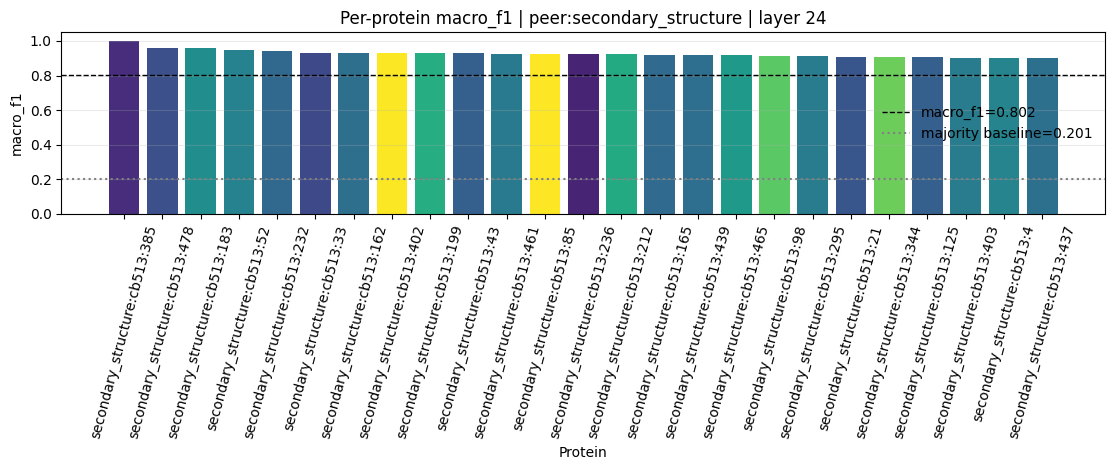

In [12]:
if per_protein.empty:
    raise EmbeddingInputError("No per-protein rows were available. Check the test split and MIN_VALID_RESIDUES.")

def resolve_per_protein_metric(per_protein: pd.DataFrame) -> str:
    if PER_PROTEIN_METRIC in per_protein.columns:
        return PER_PROTEIN_METRIC
    fallback = "macro_f1" if objective == "multiclass" and "macro_f1" in per_protein.columns else "accuracy"
    print(f"PER_PROTEIN_METRIC={PER_PROTEIN_METRIC!r} is not available for objective={objective!r}; using {fallback!r}.")
    return fallback


DISPLAY_METRIC = resolve_per_protein_metric(per_protein)

plot_df = per_protein.sort_values([DISPLAY_METRIC, "valid_residues"], ascending=[False, False]).head(TOP_N_PROTEINS).copy()
DISPLAY_SUMMARY_METRIC = SUMMARY_METRIC if SUMMARY_METRIC in probe_result.metrics else DISPLAY_METRIC
summary_value = probe_result.metrics.get(DISPLAY_SUMMARY_METRIC, float("nan"))
baseline_value = BASELINE_METRICS.get(DISPLAY_METRIC, float("nan")) if "BASELINE_METRICS" in globals() else float("nan")

fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(plot_df)), 4.8))
colors = plt.cm.viridis(plot_df["valid_residues"] / plot_df["valid_residues"].max())
ax.bar(plot_df["protein_id"], plot_df[DISPLAY_METRIC], color=colors)
if not math.isnan(summary_value):
    ax.axhline(summary_value, color="black", linestyle="--", linewidth=1, label=f"{DISPLAY_SUMMARY_METRIC}={summary_value:.3f}")
if not math.isnan(baseline_value):
    ax.axhline(baseline_value, color="gray", linestyle=":", linewidth=1.5, label=f"majority baseline={baseline_value:.3f}")
ax.legend(frameon=False)
ax.set_ylim(0, 1.05)
ax.set_ylabel(DISPLAY_METRIC)
ax.set_xlabel("Protein")
ax.set_title(f"Per-protein {DISPLAY_METRIC} | {dataset_name} | layer {probe_result.layer_index}")
ax.tick_params(axis="x", rotation=75)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

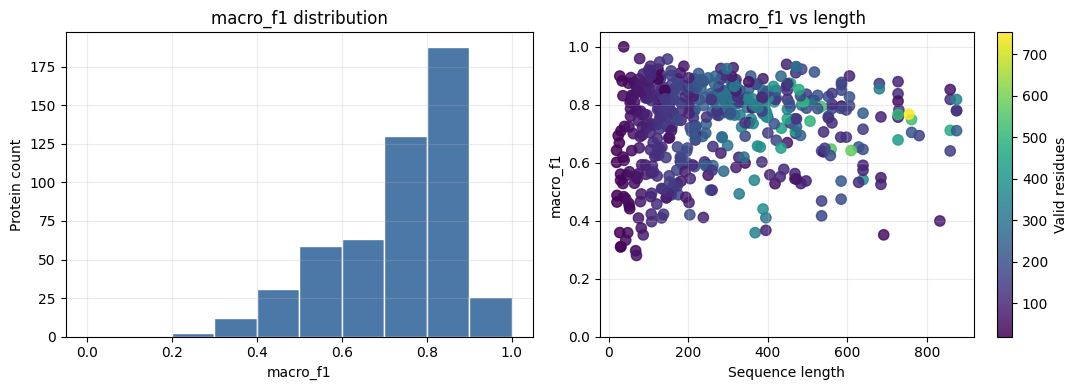

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(per_protein[DISPLAY_METRIC], bins=np.linspace(0, 1, 11), color="#4c78a8", edgecolor="white")
axes[0].set_xlabel(DISPLAY_METRIC)
axes[0].set_ylabel("Protein count")
axes[0].set_title(f"{DISPLAY_METRIC} distribution")

scatter = axes[1].scatter(
    per_protein["sequence_length"],
    per_protein[DISPLAY_METRIC],
    c=per_protein["valid_residues"],
    cmap="viridis",
    s=55,
    alpha=0.85,
)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel(DISPLAY_METRIC)
axes[1].set_title(f"{DISPLAY_METRIC} vs length")
fig.colorbar(scatter, ax=axes[1], label="Valid residues")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## True vs Predicted Labels Per Protein

Each panel shows residue position on the x-axis and the residue label on the y-axis. Blue is the true label; red is the predicted label. For binary tasks, the black line is the prediction score.

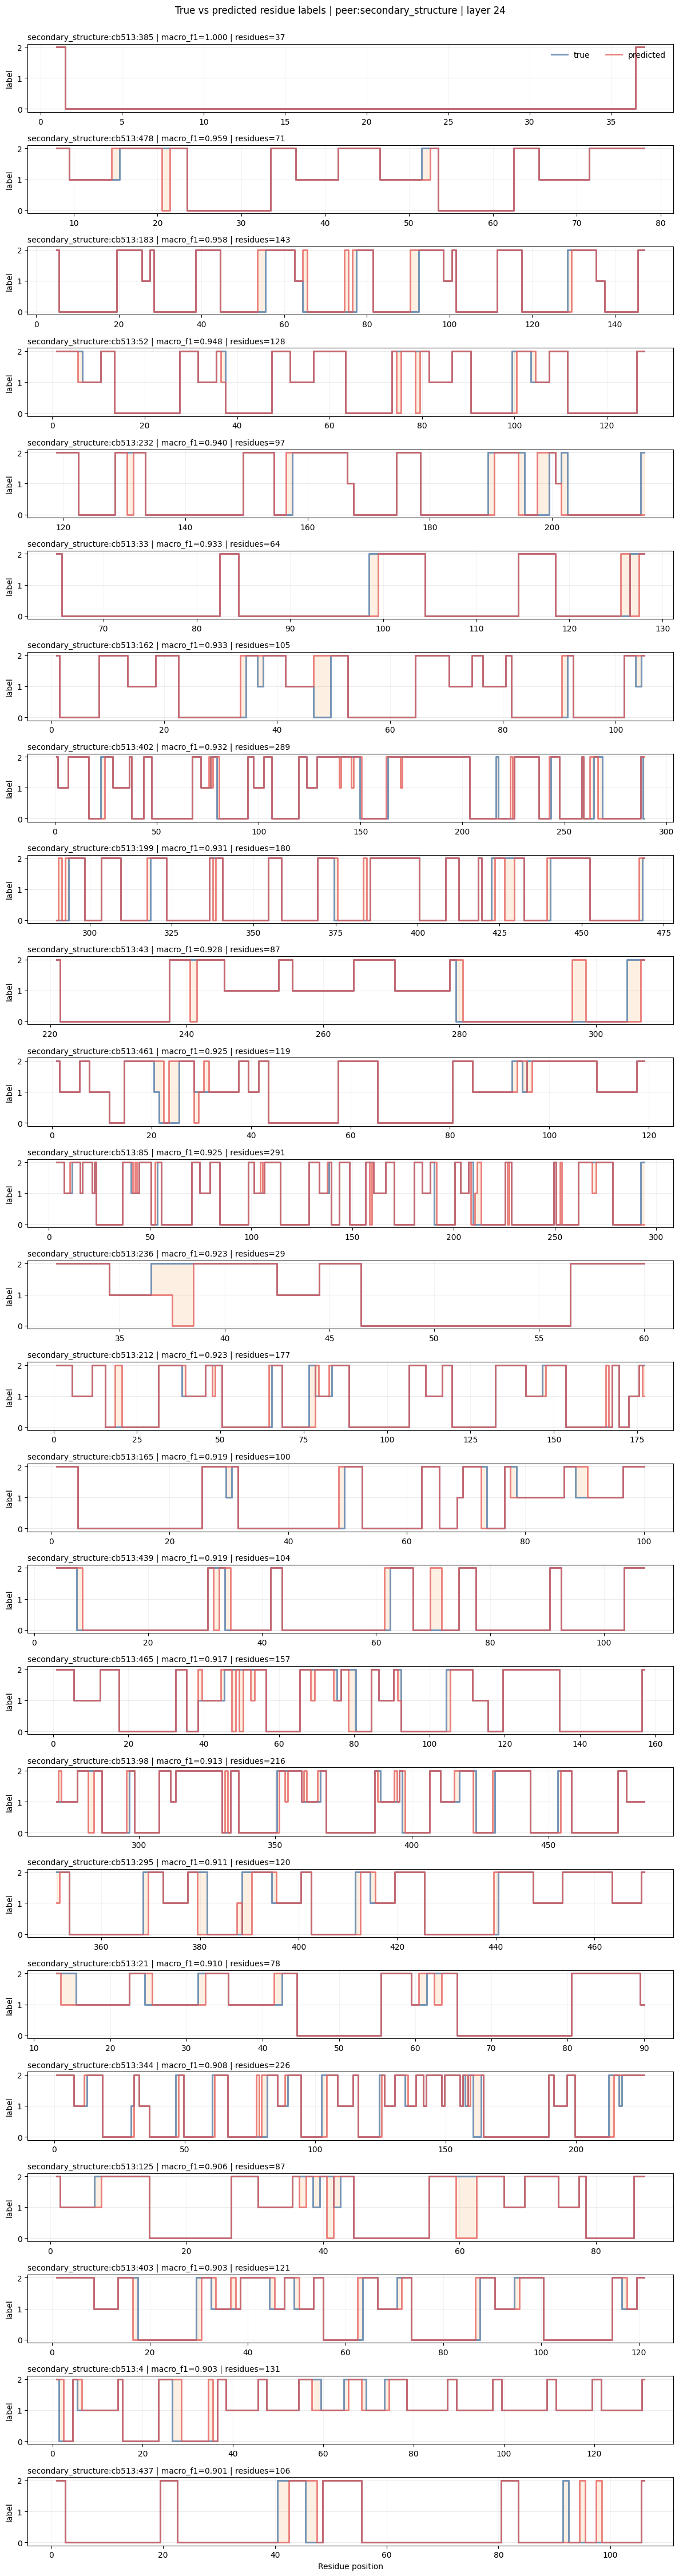

In [14]:
def _label_axis_values(values: pd.Series, class_order: list[str]) -> list[int | float]:
    if objective == "binary":
        return values.astype(int).tolist()
    class_index = {label: index for index, label in enumerate(class_order)}
    return values.map(class_index).astype(int).tolist()


selected_proteins = per_protein.sort_values([DISPLAY_METRIC, "valid_residues"], ascending=[False, False]).head(TOP_N_PROTEINS)["protein_id"].tolist()
trace_df = residue_predictions[residue_predictions["protein_id"].isin(selected_proteins)].copy()
class_order = sorted(set(trace_df["true_label"]).union(trace_df["predicted_label"]))

n = len(selected_proteins)
fig, axes = plt.subplots(n, 1, figsize=(12, max(2.6, 1.8 * n)), sharex=False, squeeze=False)
axes_flat = axes.ravel()

for ax, protein_id in zip(axes_flat, selected_proteins):
    protein_rows = trace_df[trace_df["protein_id"] == protein_id].sort_values("position")
    x = protein_rows["position"].astype(int).to_numpy()
    y_true = _label_axis_values(protein_rows["true_label"], class_order)
    y_pred = _label_axis_values(protein_rows["predicted_label"], class_order)

    ax.step(x, y_true, where="mid", linewidth=2.2, color="#4c78a8", alpha=0.75, label="true")
    ax.step(x, y_pred, where="mid", linewidth=2.0, color="#e45756", alpha=0.75, label="predicted")
    if objective == "binary" and protein_rows["score"].notna().all():
        ax.plot(x, protein_rows["score"].astype(float).to_numpy(), color="black", linewidth=1.4, alpha=0.9, label="score")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=0.9, alpha=0.45)
    ax.fill_between(x, y_true, y_pred, step="mid", color="#f58518", alpha=0.12)
    protein_metric = per_protein.loc[per_protein["protein_id"] == protein_id, DISPLAY_METRIC].iloc[0]
    ax.set_title(f"{protein_id} | {DISPLAY_METRIC}={protein_metric:.3f} | residues={len(protein_rows)}", loc="left", fontsize=10)
    ax.set_ylabel("label")
    ax.grid(axis="x", alpha=0.15)
    ax.grid(axis="y", alpha=0.25)

    if objective == "binary":
        ax.set_ylim(-0.15, 1.15)
        ax.set_yticks([0, 1])
    else:
        ax.set_yticks(range(len(class_order)))
        ax.set_yticklabels(class_order)

axes_flat[0].legend(frameon=False, ncols=3, loc="upper right")
axes_flat[-1].set_xlabel("Residue position")
fig.suptitle(f"True vs predicted residue labels | {dataset_name} | layer {probe_result.layer_index}", y=1.0)
plt.tight_layout()
plt.show()